In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

print("Imports successful!")

Imports successful!


Locate the dataset

In [2]:
DATASET_DIR = Path("../data/raw/garbage-dataset")

print("Dataset path:", DATASET_DIR.resolve())
print("Dataset exists:", DATASET_DIR.exists())

Dataset path: C:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\data\raw\garbage-dataset
Dataset exists: True


Discover the classes

In [3]:
class_names = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print(f"Number of classes: {len(class_names)}")
print("Classes:")

for class_name in class_names:
    print(f" - {class_name}")

Number of classes: 10
Classes:
 - battery
 - biological
 - cardboard
 - clothes
 - glass
 - metal
 - paper
 - plastic
 - shoes
 - trash


Build an image inventory

In [6]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for class_name in class_names:
    class_dir = DATASET_DIR / class_name

    for file_path in class_dir.iterdir():

        if file_path.is_file():

            records.append({
                "class_name": class_name,
                "file_name": file_path.name,
                "file_path": str(file_path),
                "extension": file_path.suffix.lower(),
                "is_supported_image": file_path.suffix.lower() in IMAGE_EXTENSIONS
            })

df_files = pd.DataFrame(records)

print("Total files:", len(df_files))
display(df_files.head())

Total files: 19762


,class_name,file_name,file_path,extension,is_supported_image
0,battery,battery_1.jpg,..\data\raw\garbage-dataset\battery\battery_1.jpg,.jpg,True
1,battery,battery_10.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True
2,battery,battery_100.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True
3,battery,battery_101.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True
4,battery,battery_102.jpg,..\data\raw\garbage-dataset\battery\battery_10...,.jpg,True


Check extensions

In [7]:
extension_counts = (
    df_files["extension"]
    .value_counts()
    .sort_values(ascending=False)
)

display(extension_counts)

extension
.jpg     19730
.png        31
.jpeg        1
Name: count, dtype: int64

In [8]:
unsupported_files = df_files[
    ~df_files["is_supported_image"]
]

print("Unsupported files:", len(unsupported_files))

if len(unsupported_files) > 0:
    display(unsupported_files)

Unsupported files: 0


Actual class distribution

In [9]:
class_counts = (
    df_files[df_files["is_supported_image"]]
    ["class_name"]
    .value_counts()
    .reindex(class_names)
)

class_distribution = pd.DataFrame({
    "class_name": class_counts.index,
    "image_count": class_counts.values
})

class_distribution["percentage"] = (
    class_distribution["image_count"]
    / class_distribution["image_count"].sum()
    * 100
)

display(class_distribution)

print(
    "Total supported images:",
    class_distribution["image_count"].sum()
)

,class_name,image_count,percentage
0,battery,944,4.776844
1,biological,997,5.045036
2,cardboard,1825,9.234895
3,clothes,5327,26.955774
4,glass,3061,15.489323
5,metal,1020,5.161421
6,paper,1680,8.501164
7,plastic,1984,10.039470
8,shoes,1977,10.004048
9,trash,947,4.792025


Total supported images: 19762


Visualize class imbalance

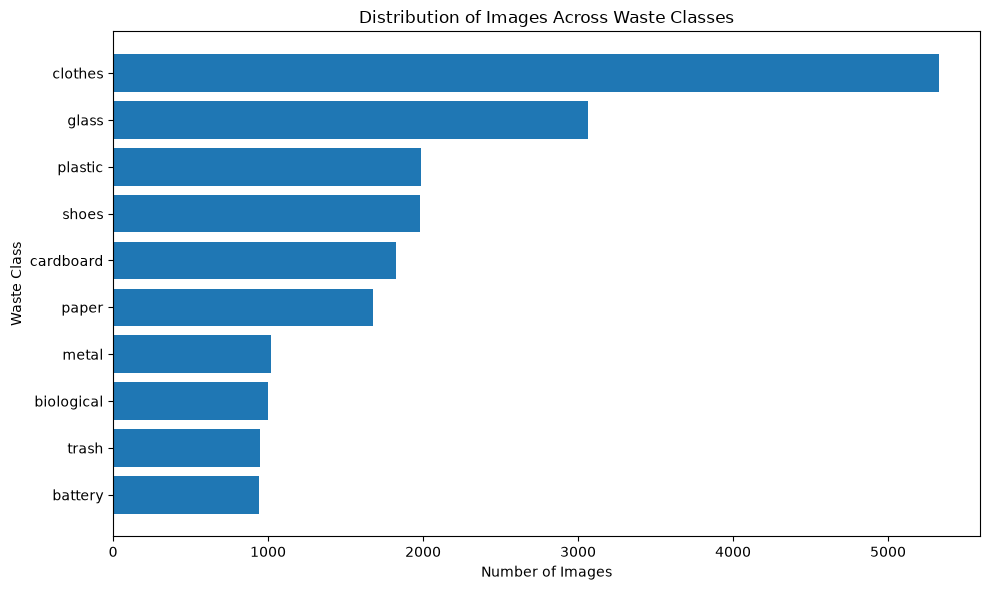

In [10]:
plot_df = class_distribution.sort_values(
    "image_count",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["class_name"],
    plot_df["image_count"]
)

plt.xlabel("Number of Images")
plt.ylabel("Waste Class")
plt.title("Distribution of Images Across Waste Classes")

plt.tight_layout()
plt.show()

Calculate imbalance statistics

In [11]:
largest_class = class_distribution.loc[
    class_distribution["image_count"].idxmax()
]

smallest_class = class_distribution.loc[
    class_distribution["image_count"].idxmin()
]

imbalance_ratio = (
    largest_class["image_count"]
    / smallest_class["image_count"]
)

print(
    f"Largest class: {largest_class['class_name']} "
    f"({largest_class['image_count']} images)"
)

print(
    f"Smallest class: {smallest_class['class_name']} "
    f"({smallest_class['image_count']} images)"
)

print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Largest class: clothes (5327 images)
Smallest class: battery (944 images)
Imbalance ratio: 5.64:1
